# Figures of *Non-asymptotic Tail Bounds for the Kostlan--Shub--Smale Field: Tensor PCA and Spherical $k$-Spin Complexity*

Single consolidated notebook reproducing the figures of
`main_Tensor_KSS_KacRice.tex`. The article embeds **two** figures,
`fig:delta_min` and `fig:threshold_inversion`; this notebook produces both,
plus one supplementary prefactor-ratio diagnostic (`delta_ratio_baseline.pdf`,
*not* embedded in the article) that visualises the asymptotic prefactor
identities of Appendix `app:prefactor_asymptotics`. Every Monte-Carlo routine
draws the same budget $N_{\mathrm{MC}}=20\,000$ GOE samples (controlled by the
global constant `N_MC` set in the imports cell).

| Notebook section | LaTeX label | Output PDF |
|---|---|---|
| Section 8  | `fig:delta_min`                    | `delta_min_comparison.pdf`       |
| Section 9  | *(supplementary, not in article)*  | `delta_ratio_baseline.pdf`       |
| Section 10 | `fig:threshold_inversion`          | `threshold_inversion_panels.pdf` |

The shared five-curve convention used in Figures 1 and 2:

* **$\delta_{\mathrm{exact}}$** --- strictly exact closed-form Kac--Rice bound
  (Theorem `thm:imf_tail_exact`); since it agrees pointwise with the Kac--Rice
  integral $\delta_0$ on $[u_{\mathrm{IMF}},\infty)$, it is the gold-standard
  reference for $\delta_0$ and no separate Monte-Carlo curve is needed.
* **$\delta_{\mathrm{bl}}$** --- asymptotic baseline of
  `eq:asymptotic_baseline_approx`. *Not* an upper bound on $\delta_0$, only
  the asymptotic equivalent as $u\to\infty$ with $d$ fixed.
* **$\delta_{\mathrm{SM}},\delta_{\mathrm{IMF}},\delta_{\mathrm{SMF}}$** ---
  the three non-asymptotic upper bounds of Table 1 (`tab:tail_bounds`).

## 1. Mathematical setup (pointer to the paper)

Fix integers $k,d\ge 3$. Let $X$ be the Kostlan--Shub--Smale random field on
$\mathbb S^{d-1}$, i.e., the unique centred Gaussian field of covariance
$\mathbb E[X(\bm \theta)X(\bm v)]=\langle\bm \theta,\bm v\rangle^k$. Set
$\rho:=\sqrt{k/(2(k-1))}\in(0,1]$ and let $G_{d-1}\sim\mathrm{GOE}(d-1)$ in
the Mehta normalization (diagonal entries $\mathcal N(0,1)$, off-diagonal
$\mathcal N(0,1/2)$). The central Kac--Rice reduction is

$$
\delta_0(u) := C_{k,d}\int_u^\infty
   \mathbb E\bigl[|\det(G_{d-1}-\rho x\,I_{d-1})|\bigr]\,\varphi(x)\,\mathrm dx,
\qquad
\mathbb P\Bigl\{\sup_{\bm \theta\in\mathbb S^{d-1}} X(\bm \theta)>u\Bigr\}\le \delta_0(u),
$$

with $C_{k,d}=2\sqrt\pi\,(k-1)^{(d-1)/2}/\Gamma(d/2)$ and
$\varphi(x)=(2\pi)^{-1/2}e^{-x^2/2}$ the standard Gaussian density.

## 2. Imports, global constants, and plotting style

The single global constant `N_MC = 20_000` controls the Monte-Carlo budget
of every Monte-Carlo routine in this notebook.

In [1]:
from __future__ import annotations

from math import factorial, gamma, sqrt, pi, exp
from typing import Callable

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import eval_hermite, erfc, comb
from scipy.optimize import bisect
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Global Monte-Carlo budget: every MC routine in this notebook draws this
# many GOE samples. Change here to scale all figures up or down at once.
N_MC = 20_000

plt.rcParams.update({
    "figure.dpi":       120,
    "savefig.dpi":      200,
    "font.size":        11,
    "axes.titlesize":   12,
    "axes.labelsize":   11,
    "legend.fontsize":  9,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "text.usetex":      False,
    "mathtext.fontset": "cm",
    "font.family":      "serif",
})

# Six-curve colour convention. Each entry maps the paper notation to a fixed
# (colour, marker, label) so Figures 1 and 2 share a consistent visual language.
CURVE_STYLE = {
    "delta0":      {"color": "k",   "ls": "",  "marker": "o", "ms": 3.0,
                    "label": r"MC of $\delta_0$"},
    "delta_exact": {"color": "C3",  "ls": "-", "marker": "",  "ms": 0,
                    "label": r"$\delta_{\mathrm{exact}}$"},
    "delta_bl":    {"color": "0.4", "ls": "--","marker": "",  "ms": 0,
                    "label": r"$\delta_{\mathrm{bl}}$"},
    "delta_SM":    {"color": "C2",  "ls": "-", "marker": "",  "ms": 0,
                    "label": r"$\delta_{\mathrm{SM}}$"},
    "delta_IMF":   {"color": "C0",  "ls": "-", "marker": "",  "ms": 0,
                    "label": r"$\delta_{\mathrm{IMF}}$"},
    "delta_SMF":   {"color": "C1",  "ls": "-", "marker": "",  "ms": 0,
                    "label": r"$\delta_{\mathrm{SMF}}$"},
}


## 3. Core quantities

These match exactly the constants of the *Explicit form of the constants*
block (`eq:expression_constants`) of the paper.

In [2]:
def rho(k: int) -> float:
    r"""Coupling constant rho_k = sqrt(k/(2(k-1))) of `eq:rho_ckd_intro`."""
    if k < 2:
        raise ValueError("rho is defined only for k >= 2.")
    return sqrt(k / (2.0 * (k - 1)))


def c_j(j: int) -> float:
    r"""Mehta orthonormalization constant c_j = (2^j j! sqrt(pi))^{-1/2}."""
    return 1.0 / sqrt((2.0 ** j) * factorial(j) * sqrt(pi))


def mu_m(m: int) -> float:
    r"""mu_m := int_R H_m(y) e^{-y^2/2} dy.

    Vanishes for odd m by parity; for m=2p, equals sqrt(2 pi) (2p)! / p!.
    See the definition under (`eq:expression_constants`).
    """
    if m % 2 == 1:
        return 0.0
    p = m // 2
    return sqrt(2 * pi) * factorial(2 * p) / factorial(p)


def double_fact(n: int) -> int:
    r"""Double factorial n!! with the convention 0!! = (-1)!! = 1."""
    if n <= 0:
        return 1
    r = 1
    while n > 0:
        r *= n
        n -= 2
    return r


def alpha_d(d: int) -> float:
    r"""Dominant Hermite coefficient alpha_d (Lemma `lem:dominant_term`).

    For d even,   alpha_d = (1/2) sqrt(d/2) c_{d-1} c_d mu_d.
    For d odd,    alpha_d = 1 / mu_{d-1}.
    """
    if d % 2 == 0:
        return 0.5 * sqrt(d / 2.0) * c_j(d - 1) * c_j(d) * mu_m(d)
    return 1.0 / mu_m(d - 1)


def beta_d(d: int) -> float:
    r"""Remainder envelope constant beta_d (Lemma `lem:dominant_term`)."""
    S = sum((factorial(2 * j) ** 2) / (factorial(j) ** 3) for j in range(d)) / sqrt(pi)
    integral, _ = quad(lambda y: (1 + y) ** d * exp(-y * y / 2), 0.0, 50.0)
    B_prime = factorial(2 * d) / factorial(d) * integral
    tildeB = max(factorial(2 * d) * (2.0 ** (d + 1)) / factorial(d), B_prime * exp(d))
    extra = (sqrt(d / 2.0) * c_j(d - 1) * c_j(d)
             * factorial(2 * d - 2) / factorial(d - 1)
             * (2.0 ** (d - 1)) * tildeB)
    return S + extra


def C_kd(k: int, d: int) -> float:
    r"""Kac--Rice geometric prefactor C_{k,d} of `eq:rho_ckd_intro`."""
    return 2.0 * sqrt(pi) * (k - 1) ** ((d - 1) / 2) / gamma(d / 2)


def thresholds(k: int, d: int) -> dict:
    r"""Validity thresholds u_IMF, u_SMF, u_SM (Section 1.3 of the paper)."""
    r = rho(k)
    return {
        "u_IMF": sqrt(2 * d - 1) / r,
        "u_SMF": 2.0 * sqrt(d),
        "u_SM":  32.0 * sqrt(d - 1) / r,
    }


## 4. Closed-form tail bounds (Table 1 of the paper)

Each function returns a NumPy array so that it can be evaluated on a grid of
levels $u$ in one vectorised call.

In [3]:
def Phi_d(d: int, rho_val: float, u: np.ndarray) -> np.ndarray:
    r"""Polynomial-rational function Phi_d(rho,u) (`eq:phi_def`)."""
    u = np.asarray(u, dtype=float)
    Lam = 2.0 * rho_val * rho_val - 1.0
    out = np.zeros_like(u)
    for kk in range((d - 2) // 2 + 1):
        out = out + (2.0 * rho_val
                     * (2.0 * Lam) ** kk
                     * double_fact(d - 2) / double_fact(d - 2 * kk - 2)
                     * (2.0 * rho_val * u) ** (d - 2 * kk - 2))
    if d % 2 == 1:
        out = out + (2.0 * Lam) ** ((d - 1) // 2) * double_fact(d - 2) / u
    return out


def Psi_d(d: int, rho_val: float, u: np.ndarray) -> np.ndarray:
    r"""Polynomial-rational function Psi_d(rho,u) (`eq:psi_def`)."""
    u = np.asarray(u, dtype=float)
    a = 1.0 + rho_val * rho_val
    out = (c_j(0) ** 2) / (a * u)
    for j in range(1, d):
        denom = a - (2 * j - 1) / (u * u)
        out = out + (c_j(j) ** 2) * (2.0 * rho_val) ** (2 * j) * u ** (2 * j - 1) / denom
    return out


def delta_bl(k: int, d: int, u: np.ndarray) -> np.ndarray:
    r"""Asymptotic baseline delta_bl(u) of `eq:asymptotic_baseline_approx`.

    NOT an upper bound on delta_0; only delta_0(u) ~ delta_bl(u) as
    u -> infty with d fixed.
    """
    u = np.asarray(u, dtype=float)
    pref = sqrt(2) * (k / 2.0) ** ((d - 1) / 2) / gamma(d / 2)
    return pref * u ** (d - 2) * np.exp(-u ** 2 / 2)


def delta_SM(k: int, d: int, u: np.ndarray) -> np.ndarray:
    r"""SM tail bound (Theorem `thm:sm_tail`)."""
    u = np.asarray(u, dtype=float)
    r = rho(k)
    theta = np.sqrt(sqrt(d - 1) / (r * u))
    eta_bulk = (1.0 + theta) ** (d - 1) - 1.0
    eta_tail = (d + 1) * 2.0 ** (d - 1) * np.exp(-2.0 * r * u * sqrt(d - 1) / 9.0)
    eta = eta_bulk + eta_tail
    pref = 2.0 * sqrt(2) * (k / 2.0) ** ((d - 1) / 2) / gamma(d / 2)
    return pref * u ** (d - 2) * np.exp(-u ** 2 / 2) * (1.0 + eta)


def delta_IMF(k: int, d: int, u: np.ndarray) -> np.ndarray:
    r"""IMF tail bound (Theorem `thm:imf_tail`). Validity u >= sqrt(2d-1)/rho."""
    u = np.asarray(u, dtype=float)
    r = rho(k)
    a = 1.0 + r * r
    return (2.0 * (k - 1) ** ((d - 1) / 2)
            * (alpha_d(d) * Phi_d(d, r, u) * np.exp(-u ** 2 / 2)
               + Psi_d(d, r, u) * np.exp(-a * u ** 2 / 2)))


def delta_SMF(k: int, d: int, u: np.ndarray) -> np.ndarray:
    r"""SMF tail bound (Theorem `thm:smf_tail`). Validity u >= 2 sqrt(d)."""
    u = np.asarray(u, dtype=float)
    return (4.0 * alpha_d(d) * (2 * k) ** ((d - 1) / 2)
              * u ** (d - 2) * np.exp(-u ** 2 / 2)
            + (2.0 ** d) * beta_d(d) * (k - 1) ** ((d - 1) / 2)
              * u ** (2 * d - 3) * np.exp(-3 * u ** 2 / 4))


## 5. Strictly exact closed-form bound $\delta_{\mathrm{exact}}$

Implements the closed-form decomposition

$$
\delta_{\mathrm{exact}}(u) \;=\; 2(k-1)^{(d-1)/2}\,[D_1+D_2+D_3+D_4]
$$

of Theorem `thm:imf_tail_exact` (Section `sub:exact_mf` of the paper). It is
the tightest closed-form expression derivable from the Kac--Rice reduction,
and coincides with the Kac--Rice integral $\delta_0$ pointwise on
$[u_{\mathrm{IMF}},\infty)$ (Theorem `thm:imf_tail_exact`), so it serves as the
gold-standard reference for $\delta_0$ throughout.

In [4]:
def J_beta(m: int, t: float, beta: float) -> float:
    r"""Closed-form Hermite-Gaussian tail integral J_m^beta(t) (Lemma `lem:Jm_beta`)."""
    if m == 0:
        return sqrt(2 * pi / beta) * 0.5 * erfc(t * sqrt(beta) / sqrt(2))
    if m == 1:
        return (2.0 / beta) * exp(-beta * t * t / 2)
    g = 2.0 / beta
    th = (2.0 - beta) / beta
    s = 0.0
    for k in range(((m - 1) // 2) + 1):
        s += g * (2 * th) ** k * double_fact(m - 1) / double_fact(m - 2 * k - 1) * eval_hermite(m - 2 * k - 1, t)
    s *= exp(-beta * t * t / 2)
    if m % 2 == 0:
        s += (2 * th) ** (m // 2) * double_fact(m - 1) * (sqrt(2 * pi / beta) * 0.5 * erfc(t * sqrt(beta) / sqrt(2)))
    return s


def K_beta(j: int, t: float, beta: float) -> float:
    r"""Closed-form squared-Hermite tail K_j^beta(t) (Corollary `cor:Kj_beta`)."""
    return sum(2.0 ** p * factorial(p) * comb(j, p) ** 2 * J_beta(2 * j - 2 * p, t, beta)
               for p in range(j + 1))


def D_linear(d: int, k: int, u: float) -> float:
    r"""Linear Hermite tail L_d(u) = (1/rho) J_{d-1}^{1/rho^2}(rho u)."""
    r = rho(k)
    return J_beta(d - 1, r * u, 1.0 / (r * r)) / r


def D_1_term(d: int, k: int, u: float) -> float:
    """D_1: zero for d odd."""
    if d % 2 != 0:
        return 0.0
    return 0.5 * sqrt(d / 2) * c_j(d - 1) * c_j(d) * mu_m(d) * D_linear(d, k, u)


def D_3_term(d: int, k: int, u: float) -> float:
    """D_3: zero for d even."""
    if d % 2 == 0:
        return 0.0
    return D_linear(d, k, u) / mu_m(d - 1)


def D_4_term(d: int, k: int, u: float) -> float:
    """D_4: squared-Hermite tail T_d^exact (Theorem `thm:imf_tail_sharp`)."""
    r = rho(k)
    beta = (1 + r * r) / (r * r)
    return sum(c_j(j) ** 2 * K_beta(j, r * u, beta) for j in range(d)) / r


def D_2_term(d: int, k: int, u: float) -> float:
    """D_2: cross integral C_d(u) closed form via Lemma 12 + product
       linearization + Lemma `lem:Jm_beta`, plus Fubini remainder F_d(u) for
       d even (eq:Fubini_F)."""
    r = rho(k)
    beta = (1 + r * r) / (r * r)
    inner = 0.0
    for kk in range((d - 1) // 2 + 1):
        coef = 2.0 ** (kk + 1) * double_fact(d - 1) / double_fact(d - 2 * kk - 1)
        m1, m2 = d - 1, d - 2 * kk - 1
        prod_int = 0.0
        for p in range(min(m1, m2) + 1):
            M = m1 + m2 - 2 * p
            prod_int += (2.0 ** p * factorial(p) * comb(m1, p) * comb(m2, p)
                         * J_beta(M, r * u, beta) / r)
        inner += coef * prod_int
    if d % 2 == 0:
        coef_R = 2.0 ** (d / 2) * double_fact(d - 1)
        Phi_bar = 0.5 * erfc(r * u / sqrt(2))
        F_d = sqrt(2 * pi) * Phi_bar * D_linear(d, k, u)
        Lam = 2 * r * r - 1
        for kk in range((d - 2) // 2 + 1):
            F_d -= (2 * r * (2 * Lam) ** kk
                    * double_fact(d - 2) / double_fact(d - 2 * kk - 2)
                    * J_beta(d - 2 * kk - 2, r * u, beta))
        inner += coef_R * F_d
    return -sqrt(d / 2) * c_j(d - 1) * c_j(d) * inner


def delta_exact(k: int, d: int, u_grid) -> np.ndarray:
    r"""Strictly exact closed-form tail bound (Theorem `thm:imf_tail_exact`)."""
    u_arr = np.atleast_1d(np.asarray(u_grid, dtype=float))
    out = np.empty_like(u_arr)
    pref = 2.0 * (k - 1) ** ((d - 1) / 2)
    for i, u in enumerate(u_arr):
        d1 = D_1_term(d, k, u)
        d2 = D_2_term(d, k, u)
        d3 = D_3_term(d, k, u)
        d4 = D_4_term(d, k, u)
        out[i] = pref * (d1 + d2 + d3 + d4)
    return out


## 6. Monte-Carlo evaluation of $\delta_0(u)$

We sample $G_{d-1}\sim\mathrm{GOE}(d-1)$ and evaluate $\delta_0(u)$ by
trapezoidal quadrature on a dense $x$-grid. The same sample bank is reused
across grid points to reduce variance.

The auxiliary `delta0_ratio_mc` routine evaluates
$\delta_0(u)/u^{d-2}e^{-u^2/2}$ via the substitution $x=u+t$, which avoids
the underflow that breaks the direct estimator beyond $u\approx 20$.

Both routines default to $N_{\mathrm{MC}}$ GOE samples (=`N_MC`).

In [5]:
def sample_GOE(n: int, rng: np.random.Generator) -> np.ndarray:
    r"""One GOE(n) matrix in the Mehta normalization (var(diag)=1, var(off-diag)=1/2)."""
    A = rng.standard_normal((n, n))
    return 0.5 * (A + A.T)


def expected_abs_det(k: int, d: int, x_grid: np.ndarray,
                     n_samples: int = N_MC, seed: int = 2026) -> np.ndarray:
    r"""Monte-Carlo estimate of D_{k,d}(x) = E[|det(G_{d-1} - rho x I)|]."""
    rng = np.random.default_rng(seed)
    n = d - 1
    r = rho(k)
    Gs = np.stack([sample_GOE(n, rng) for _ in range(n_samples)], axis=0)
    I = np.eye(n)
    out = np.empty_like(x_grid, dtype=float)
    for i, xv in enumerate(x_grid):
        out[i] = np.abs(np.linalg.det(Gs - r * xv * I)).mean()
    return out


def delta0_mc(k: int, d: int, u_grid: np.ndarray,
              n_samples: int = N_MC, seed: int = 2026,
              x_pad: float = 8.0, n_dense: int = 2001) -> np.ndarray:
    r"""Monte-Carlo estimate of delta_0(u) on a level grid."""
    x_max = float(np.max(u_grid)) + x_pad
    x_dense = np.linspace(0.0, x_max, n_dense)
    D_dense = expected_abs_det(k, d, x_dense, n_samples=n_samples, seed=seed)
    phi = np.exp(-x_dense ** 2 / 2.0) / sqrt(2 * pi)
    integrand = D_dense * phi
    dx = np.diff(x_dense)
    segs = 0.5 * (integrand[:-1] + integrand[1:]) * dx
    rev_cum = np.concatenate([np.cumsum(segs[::-1])[::-1], [0.0]])
    return C_kd(k, d) * np.interp(u_grid, x_dense, rev_cum)


def delta0_ratio_mc(k: int, d: int, u_grid: np.ndarray,
                    n_samples: int = N_MC, seed: int = 2026,
                    n_t: int = 401, t_max: float | None = None) -> np.ndarray:
    r"""Stable Monte-Carlo estimate of delta_0(u) / (u^{d-2} e^{-u^2/2})."""
    rng = np.random.default_rng(seed)
    n = d - 1
    r = rho(k)
    Gs = np.stack([sample_GOE(n, rng) for _ in range(n_samples)], axis=0)
    I = np.eye(n)
    ratios = np.empty_like(u_grid, dtype=float)
    for i, u in enumerate(u_grid):
        tmax = t_max if t_max is not None else max(32.0 / max(u, 1.0), 3.0)
        t = np.linspace(0.0, tmax, n_t)
        D_vals = np.empty_like(t)
        for j, tj in enumerate(t):
            D_vals[j] = np.abs(np.linalg.det(Gs - r * (u + tj) * I)).mean()
        weight = np.exp(-u * t - t ** 2 / 2.0)
        integrand = D_vals * weight
        # np.trapezoid (NumPy >= 2.0) replaces the legacy np.trapz; fall back
        # to np.trapz when running against older NumPy installations.
        try:
            _trapz = np.trapezoid
        except AttributeError:
            _trapz = np.trapz
        integral = _trapz(integrand, t)
        ratios[i] = C_kd(k, d) / sqrt(2 * pi) * u ** (-(d - 2)) * integral
    return ratios


def build_KR_MC(k: int, d: int, x_max: float = 25.0, n_grid: int = 4001,
                n_samples: int = N_MC, seed: int = 2026):
    r"""Precompute u |-> delta_0(u) on a dense x-grid suitable for bisection."""
    rng = np.random.default_rng(seed)
    n = d - 1
    r = rho(k)
    Gs = np.stack([sample_GOE(n, rng) for _ in range(n_samples)], axis=0)
    x_dense = np.linspace(0.0, x_max, n_grid)
    I = np.eye(n)
    D = np.empty_like(x_dense)
    for i, xv in enumerate(x_dense):
        D[i] = np.abs(np.linalg.det(Gs - r * xv * I)).mean()
    phi = np.exp(-x_dense ** 2 / 2.0) / sqrt(2 * pi)
    integrand = D * phi
    dx = np.diff(x_dense)
    segs = 0.5 * (integrand[:-1] + integrand[1:]) * dx
    rev_cum = np.concatenate([np.cumsum(segs[::-1])[::-1], [0.0]])
    KR = C_kd(k, d) * rev_cum
    return x_dense, KR


def asymptotic_prefactors(k: int, d: int) -> dict:
    P_bl  = sqrt(2) * (k / 2.0) ** ((d - 1) / 2) / gamma(d / 2)
    P_IMF = 2.0 * alpha_d(d) * (2 * k) ** ((d - 1) / 2)
    return {"P_bl": P_bl, "P_SM": 2.0 * P_bl,
            "P_IMF": P_IMF, "P_SMF": 2.0 * P_IMF}


## 7. Sanity check on the constants

For each representative pair $(k,d)\in\{(3,5),(4,6)\}$, we print the validity
thresholds $u_{\mathrm{IMF}},u_{\mathrm{SMF}},u_{\mathrm{SM}}$ of Section 1.3,
the explicit constants $\alpha_d,\beta_d$ of `eq:expression_constants`, and the
four asymptotic prefactors
$P_{\mathrm{bl}},P_{\mathrm{SM}},P_{\mathrm{IMF}},P_{\mathrm{SMF}}$ of the
prefactor analysis (Appendix `app:prefactor_asymptotics`). The identity
$P_{\mathrm{IMF}}=P_{\mathrm{bl}}$ is the hallmark of the IMF analysis: only
the IMF bound recovers the exact baseline prefactor, while SM and SMF each
incur the uniform factor $2$ ($P_{\mathrm{SM}}=P_{\mathrm{SMF}}=2P_{\mathrm{bl}}$).

In [6]:
for (k, d) in [(3, 5), (4, 6)]:
    th = thresholds(k, d)
    P  = asymptotic_prefactors(k, d)
    print(f"(k, d) = ({k}, {d})  rho = {rho(k):.4f}")
    print(f"  u_IMF = {th['u_IMF']:.3f}   u_SMF = {th['u_SMF']:.3f}   u_SM = {th['u_SM']:.3f}")
    print(f"  alpha_d = {alpha_d(d):.3e}   beta_d = {beta_d(d):.3e}")
    print(f"  P_bl  = {P['P_bl']:.4f}   P_SM  = {P['P_SM']:.4f}")
    print(f"  P_IMF = {P['P_IMF']:.4f}   P_SMF = {P['P_SMF']:.4f}")
    print()


(k, d) = (3, 5)  rho = 0.8660
  u_IMF = 3.464   u_SMF = 4.472   u_SM = 73.901
  alpha_d = 3.325e-02   beta_d = 5.813e+09
  P_bl  = 2.3937   P_SM  = 4.7873
  P_IMF = 2.3937   P_SMF = 4.7873

(k, d) = (4, 6)  rho = 0.8165
  u_IMF = 4.062   u_SMF = 4.899   u_SM = 87.636
  alpha_d = 1.105e-02   beta_d = 3.611e+12
  P_bl  = 4.0000   P_SM  = 8.0000
  P_IMF = 4.0000   P_SMF = 8.0000



## 8. Figure 1 -- `delta_min_comparison.pdf` (`fig:delta_min`)

The five closed-form curves $\delta_{\mathrm{exact}}$, $\delta_{\mathrm{bl}}$,
$\delta_{\mathrm{SM}}$, $\delta_{\mathrm{IMF}}$, $\delta_{\mathrm{SMF}}$ are
plotted on a logarithmic scale against the level $u$ for $(k,d)=(3,5)$ (left)
and $(k,d)=(4,6)$ (right). The strictly exact $\delta_{\mathrm{exact}}$ of
Theorem `thm:imf_tail_exact` is the gold-standard reference for $\delta_0$: it
is the closed-form evaluation of the Kac--Rice integral `eq:KR_combined_intro`
and equals $\delta_0$ pointwise on $[u_{\mathrm{IMF}},\infty)$. All curves
start at $u=u_{\mathrm{IMF}}$; the $\delta_{\mathrm{SM}}$ expression is shown
below its own validity threshold $u_{\mathrm{SM}}$ (well outside the displayed
range in both panels) only to make the comparison with $\delta_{\mathrm{IMF}}$
and $\delta_{\mathrm{SMF}}$ visible -- it ceases to be a bound below
$u_{\mathrm{SM}}$.

$\delta_{\mathrm{IMF}}$ is visually indistinguishable from
$\delta_{\mathrm{exact}}$, confirming that the Hermite-tail analysis is
asymptotically sharp; $\delta_{\mathrm{SMF}}$ (Szeg\H{o} envelope) and
$\delta_{\mathrm{SM}}$ (correction factor $1+\eta_d(\rho,u)$) sit visibly above
by their predicted factors, while the baseline $\delta_{\mathrm{bl}}$ tracks
$\delta_{\mathrm{exact}}$ from below (it is not a bound). A boxed inset zooms
onto the moderate-$u$ region $u\in[11,14]$ where the gap between
$\delta_{\mathrm{IMF}},\delta_{\mathrm{exact}}$ and $\delta_{\mathrm{bl}}$ is
most apparent.

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_80521/1773531563.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


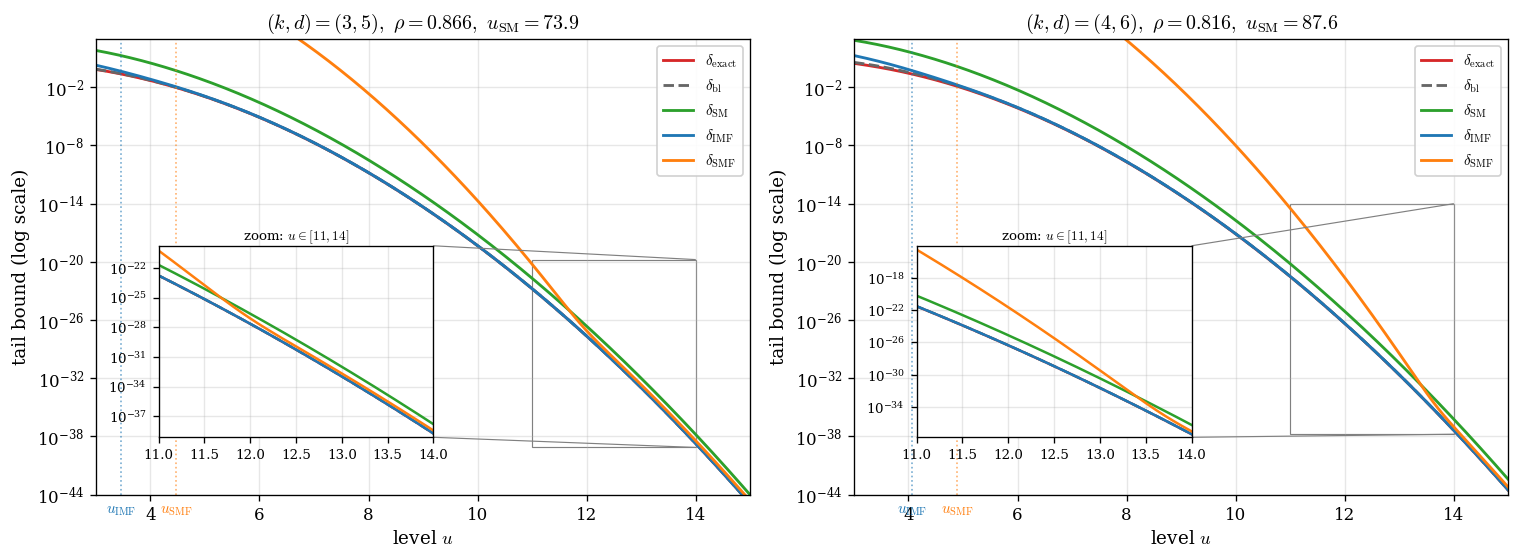

In [7]:
def plot_delta_min(cases=((3, 5), (4, 6)), u_min=3.0, u_max=15.0, n_u=400,
                   n_samples=N_MC, savename="delta_min_comparison.pdf"):
    fig, axes = plt.subplots(1, len(cases), figsize=(6.4 * len(cases), 4.8),
                             sharey=False)
    axes = np.atleast_1d(axes)
    u = np.linspace(u_min, u_max, n_u)

    for ax, (k, d) in zip(axes, cases):
        r  = rho(k)
        th = thresholds(k, d)

        dexact_curve = delta_exact(k, d, u)
        dbl_curve    = delta_bl(k, d, u)
        dSM_curve    = delta_SM(k, d, u)
        dIM_curve    = delta_IMF(k, d, u)
        dSF_curve    = delta_SMF(k, d, u)

        for arr, key in [(dexact_curve, "delta_exact"),
                         (dbl_curve, "delta_bl"),
                         (dSM_curve, "delta_SM"), (dIM_curve, "delta_IMF"),
                         (dSF_curve, "delta_SMF")]:
            sty = CURVE_STYLE[key].copy()
            label = sty.pop("label")
            ax.semilogy(u, arr, label=label, lw=1.7, **sty)

        for thr, lbl, col in [(th["u_IMF"], r"$u_{\mathrm{IMF}}$", "C0"),
                              (th["u_SMF"], r"$u_{\mathrm{SMF}}$", "C1")]:
            ax.axvline(thr, color=col, ls=":", lw=1.0, alpha=0.6)
            ax.text(thr, -0.02, lbl, color=col,
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=9)

        ax.set_title(fr"$(k,d)=({k},{d}),\ \rho={r:.3f},\ u_{{\mathrm{{SM}}}}={th['u_SM']:.1f}$")
        ax.set_xlabel(r"level $u$")
        ax.set_ylabel(r"tail bound (log scale)")
        ax.set_xlim(u_min, u_max)
        ax.set_ylim(1e-44, 1e3)
        ax.legend(loc="upper right", framealpha=0.9)

        u_zoom_lo, u_zoom_hi = 11.0, 14.0
        zmask = (u >= u_zoom_lo) & (u <= u_zoom_hi)
        all_zoom = np.concatenate([dexact_curve[zmask],
                                   dbl_curve[zmask], dSM_curve[zmask],
                                   dIM_curve[zmask], dSF_curve[zmask]])
        all_zoom = all_zoom[np.isfinite(all_zoom) & (all_zoom > 0)]
        y_lo = max(all_zoom.min() * 0.3, 1e-44)
        y_hi = all_zoom.max() * 3.0

        axins = inset_axes(ax, width="42%", height="42%", loc="lower left",
                           bbox_to_anchor=(0.05, 0.06, 1, 1),
                           bbox_transform=ax.transAxes, borderpad=2.0)
        for arr, key in [(dexact_curve, "delta_exact"),
                         (dbl_curve, "delta_bl"), (dSM_curve, "delta_SM"),
                         (dIM_curve, "delta_IMF"), (dSF_curve, "delta_SMF")]:
            sty = CURVE_STYLE[key].copy()
            sty.pop("label")
            axins.semilogy(u, arr, lw=1.5, **sty)
        axins.set_xlim(u_zoom_lo, u_zoom_hi)
        axins.set_ylim(y_lo, y_hi)
        axins.tick_params(axis="both", which="both", labelsize=8)
        axins.set_title(r"zoom: $u\in[11,14]$", fontsize=8, pad=2)
        axins.grid(alpha=0.3)
        mark_inset(ax, axins, loc1=1, loc2=4, fc="none", ec="0.5", lw=0.7)

    fig.tight_layout()
    if savename:
        fig.savefig(savename, bbox_inches="tight")
    plt.show()


plot_delta_min()


## 9. Figure 2 -- `delta_ratio_baseline.pdf` (supplementary diagnostic)

*Supplementary figure, not embedded in `main_Tensor_KSS_KacRice.tex`.* It
visualises the asymptotic prefactor identities behind the *Asymptotic
optimality of the prefactors* paragraph (Section 1.3) and
Appendix `app:prefactor_asymptotics`.

Each of the five closed-form curves is divided by the leading rate
$f(u)=u^{d-2}e^{-u^2/2}$ and plotted on a logarithmic scale.

The horizontal asymptote of each ratio is its asymptotic prefactor; the
identity $\lim_{u\to\infty}\delta_{\mathrm{IMF}}(u)/f(u)=P_{\mathrm{bl}}$ of
Theorem `thm:imf_tail` predicts that the IMF and exact curves both rest on
$P_{\mathrm{bl}}$ -- with $\delta_{\mathrm{exact}}/f$ approaching it *from
below* (see the inset) -- while the SM and SMF curves flatten at the
factor-of-$2$ height $2P_{\mathrm{bl}}$.

/var/folders/k2/mf0jqmf15635bbb9j41fz41w0000gq/T/ipykernel_80521/2817936890.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


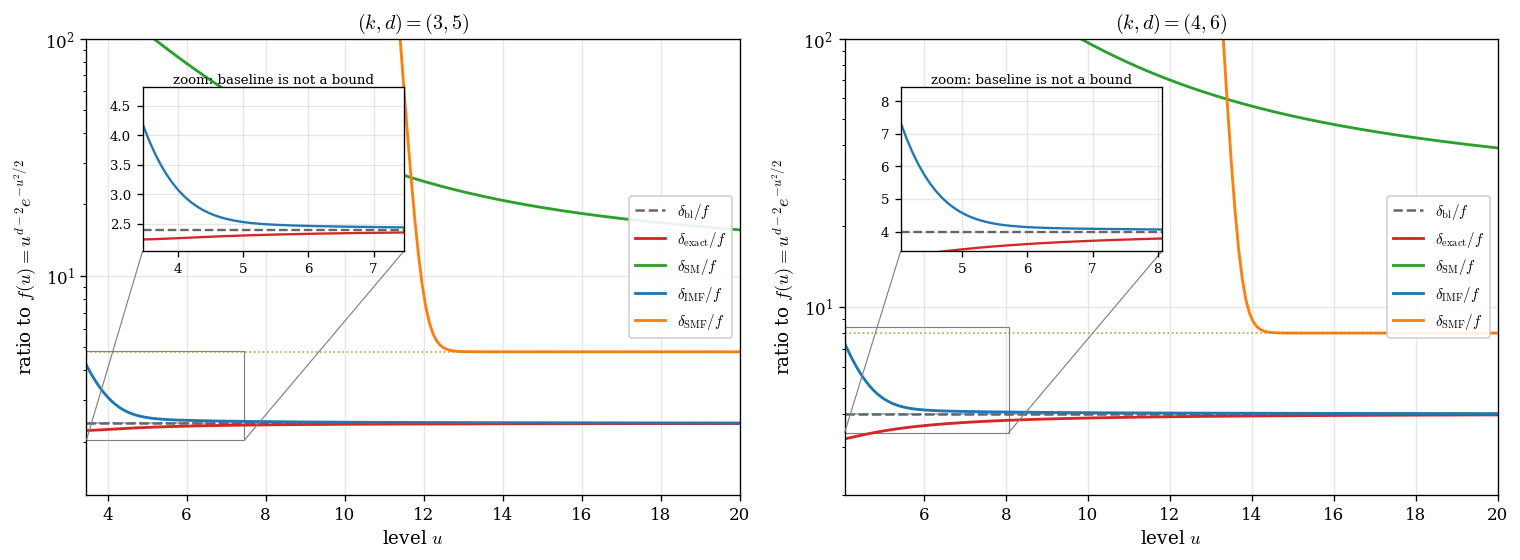

In [8]:
def plot_delta_ratio_baseline(cases=((3, 5), (4, 6)), u_max=20.0, n_u=180,
                              n_samples_mc=N_MC, n_t=401,
                              savename="delta_ratio_baseline.pdf"):
    fig, axes = plt.subplots(1, len(cases), figsize=(6.4 * len(cases), 4.8),
                             sharey=False)
    axes = np.atleast_1d(axes)

    for ax, (k, d) in zip(axes, cases):
        th = thresholds(k, d)
        P  = asymptotic_prefactors(k, d)

        u_lo = th["u_IMF"] + 1e-3
        u = np.linspace(u_lo, u_max, n_u)
        r = rho(k)

        ratio_bl = np.full_like(u, P["P_bl"])

        theta = np.sqrt(sqrt(d - 1) / (r * u))
        eta_bulk = (1.0 + theta) ** (d - 1) - 1.0
        eta_tail = (d + 1) * 2.0 ** (d - 1) * np.exp(-2.0 * r * u * sqrt(d - 1) / 9.0)
        eta = eta_bulk + eta_tail
        pref_SM = 2.0 * sqrt(2) * (k / 2.0) ** ((d - 1) / 2) / gamma(d / 2)
        ratio_SM = pref_SM * (1.0 + eta)

        ratio_IMF = (2.0 * (k - 1) ** ((d - 1) / 2)
                     * (alpha_d(d) * Phi_d(d, r, u) / u ** (d - 2)
                        + Psi_d(d, r, u) * np.exp(-r * r * u ** 2 / 2)
                          / u ** (d - 2)))

        ratio_SMF = (4.0 * alpha_d(d) * (2 * k) ** ((d - 1) / 2)
                     + (2.0 ** d) * beta_d(d) * (k - 1) ** ((d - 1) / 2)
                       * u ** (d - 1) * np.exp(-u ** 2 / 4))

        f_u = u ** (d - 2) * np.exp(-u ** 2 / 2)
        ratio_exact = delta_exact(k, d, u) / f_u

        sty_exact = CURVE_STYLE["delta_exact"].copy(); sty_exact.pop("label")
        sty_bl  = CURVE_STYLE["delta_bl"].copy();  sty_bl.pop("label")
        sty_SM  = CURVE_STYLE["delta_SM"].copy();  sty_SM.pop("label")
        sty_IMF = CURVE_STYLE["delta_IMF"].copy(); sty_IMF.pop("label")
        sty_SMF = CURVE_STYLE["delta_SMF"].copy(); sty_SMF.pop("label")

        ax.plot(u,  ratio_bl,    lw=1.5, label=r"$\delta_{\mathrm{bl}}/f$", **sty_bl)
        ax.plot(u,  ratio_exact, lw=1.7, label=r"$\delta_{\mathrm{exact}}/f$", **sty_exact)
        ax.plot(u,  ratio_SM,    lw=1.7, label=r"$\delta_{\mathrm{SM}}/f$", **sty_SM)
        ax.plot(u,  ratio_IMF,   lw=1.7, label=r"$\delta_{\mathrm{IMF}}/f$", **sty_IMF)
        ax.plot(u,  ratio_SMF,   lw=1.7, label=r"$\delta_{\mathrm{SMF}}/f$", **sty_SMF)

        for key, color, ls in [("P_bl",  "0.4", "--"),
                               ("P_SM",  "C2",  ":"),
                               ("P_IMF", "C0",  ":"),
                               ("P_SMF", "C1",  ":")]:
            ax.axhline(P[key], color=color, ls=ls, lw=1.0, alpha=0.5)

        ax.set_yscale("log")
        ax.set_xlim(u_lo, u_max)
        ax.set_ylim(0.5 * P["P_bl"], 1e2)
        ax.set_xlabel(r"level $u$")
        ax.set_ylabel(r"ratio to $f(u)=u^{d-2}e^{-u^2/2}$")
        ax.set_title(fr"$(k,d)=({k},{d})$")
        ax.legend(loc="center right", framealpha=0.9)

        u_zoom_lo = u_lo
        u_zoom_hi = min(u_lo + 4.0, u_max - 1.0)
        axins = inset_axes(ax, width="40%", height="36%", loc="upper left",
                           bbox_to_anchor=(0.04, -0.04, 1, 1),
                           bbox_transform=ax.transAxes, borderpad=2.0)
        axins.plot(u, ratio_bl,    lw=1.4, **sty_bl)
        axins.plot(u, ratio_exact, lw=1.4, **sty_exact)
        axins.plot(u, ratio_IMF,   lw=1.4, **sty_IMF)
        axins.set_xlim(u_zoom_lo, u_zoom_hi)
        zmask = (u >= u_zoom_lo) & (u <= u_zoom_hi)
        cluster_max = max(ratio_IMF[zmask].max(), ratio_exact[zmask].max(), P["P_bl"])
        axins.set_ylim(0.85 * P["P_bl"], 1.15 * cluster_max)
        axins.tick_params(axis="both", which="both", labelsize=8)
        axins.set_title("zoom: baseline is not a bound", fontsize=8, pad=2)
        axins.grid(alpha=0.3)
        mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.5", lw=0.7)

    fig.tight_layout()
    if savename:
        fig.savefig(savename, bbox_inches="tight")
    plt.show()


plot_delta_ratio_baseline()


## 10. Figure 3 -- `threshold_inversion_panels.pdf` (`fig:threshold_inversion`)

Numerical inversion of the **two-sided** master tail bound at significance
levels $\alpha\in\{10^{-3},5\times 10^{-2}\}$ for $(k,d)\in\{(3,5),(4,6)\}$.

The LRT statistic over the sign-symmetric feasible set $\mathcal C_{R,\kappa}$
is the two-sided supremum $\Gamma_{R,\kappa}$, so Type-I calibration is governed
by the two-sided master bound $\delta_{\min}(u)=2\,\delta_{\mathrm{IMF}}(u)$
(`eq:delta_min`/`eq:type_one`), *not* the one-sided $\delta_{\mathrm{IMF}}$. In
each panel we display:

* the two-sided IMF curve $u\mapsto\delta_{\min}(u)=2\,\delta_{\mathrm{IMF}}(u)$ (blue);
* the two-sided exact curve $u\mapsto 2\,\delta_{\mathrm{exact}}(u)$ of Theorem
  `thm:imf_tail_exact` (black dashed);
* the horizontal target level $\alpha$ (red dotted);
* the threshold $u_\alpha$ obtained by bisecting $\delta_{\min}(u)-\alpha$
  (blue dotted vertical);
* the exact threshold $u_\alpha^{\mathrm{exact}}$ obtained by bisecting
  $2\,\delta_{\mathrm{exact}}(u)-\alpha$ (black dotted vertical).

Since $\delta_{\mathrm{exact}}\le\delta_{\mathrm{IMF}}$ one has
$u_\alpha^{\mathrm{exact}}\le u_\alpha$, so the IMF threshold is a conservative
surrogate. The LRT of Section `sub:info_theory` rejects $H_0$ when
$\hat\lambda_{\mathrm{LRT}}>(\sqrt R/\kappa)\,u_\alpha$ (the rank-reduction
inflation of Lemma `lem:reduce_rank_one`; for rank-one detection
$R=\kappa=1$ the factor is $1$), which guarantees Type-I error at most $\alpha$.

(k,d)=(3,5), alpha=0.001: u_alpha[delta_min]=5.18810, u_exact[2*delta_exact]=5.17006, |diff|=1.80e-02
(k,d)=(3,5), alpha=0.05: u_alpha[delta_min]=4.26000, u_exact[2*delta_exact]=4.19746, |diff|=6.25e-02
(k,d)=(4,6), alpha=0.001: u_alpha[delta_min]=5.65009, u_exact[2*delta_exact]=5.61683, |diff|=3.33e-02
(k,d)=(4,6), alpha=0.05: u_alpha[delta_min]=4.80498, u_exact[2*delta_exact]=4.71424, |diff|=9.07e-02


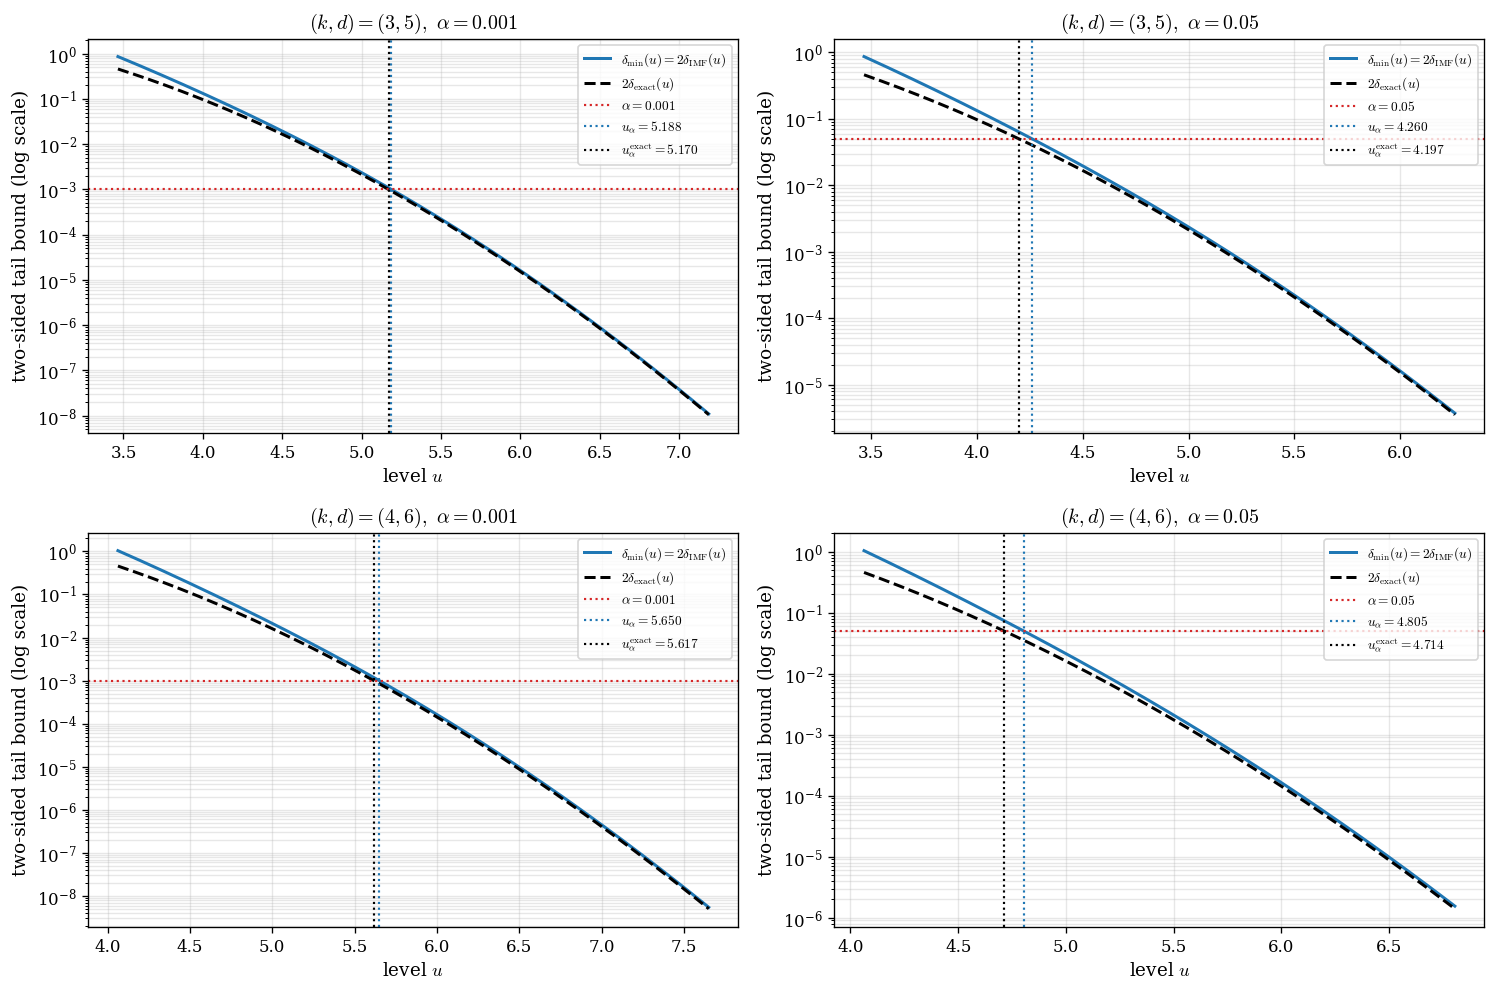

In [9]:
def invert_delta_min(k: int, d: int, alpha: float, u_lo=None, u_hi: float = 60.0) -> float:
    """Smallest u with the two-sided master bound delta_min(u)=2*delta_IMF(u) <= alpha,
    by bisection on [u_IMF, u_hi]. This is the level u_alpha of eq:type_one / eq:delta_min."""
    if u_lo is None:
        u_lo = sqrt(2 * d - 1) / rho(k) + 1e-3
    f = lambda u: 2.0 * float(delta_IMF(k, d, np.array(u))) - alpha
    if f(u_lo) <= 0.0:
        return u_lo
    if f(u_hi) > 0.0:
        raise RuntimeError(f"delta_min still > alpha at u={u_hi}")
    return bisect(f, u_lo, u_hi, xtol=1e-7, rtol=1e-9)


def invert_two_delta_exact(k: int, d: int, alpha: float, u_lo: float,
                           u_hi: float = 60.0) -> float:
    """Smallest u with the two-sided exact bound 2*delta_exact(u) <= alpha."""
    f = lambda u: 2.0 * float(delta_exact(k, d, np.array([u]))[0]) - alpha
    if f(u_lo) <= 0.0:
        return u_lo
    if f(u_hi) > 0.0:
        raise RuntimeError(f"2*delta_exact still > alpha at u={u_hi}")
    return bisect(f, u_lo, u_hi, xtol=1e-7, rtol=1e-9)


def plot_threshold_inversion_panels(
    cases=((3, 5), (4, 6)),
    alphas=(1e-3, 5e-2),
    savename="threshold_inversion_panels.pdf",
):
    """2x2 grid: rows = (k,d); columns = alpha.

    The LRT statistic over the sign-symmetric feasible set is the *two-sided*
    supremum Gamma_{R,kappa}, so Type-I calibration is governed by the two-sided
    master bound delta_min(u) = 2*delta_IMF(u) of eq:delta_min, not the one-sided
    delta_IMF. We therefore invert delta_min (and 2*delta_exact) at level alpha;
    the LRT critical value is (sqrt R / kappa) * u_alpha (for rank-one detection
    R = kappa = 1 this inflation factor is 1). See Section sub:info_theory.
    """
    fig, axes = plt.subplots(len(cases), len(alphas),
                             figsize=(6.3 * len(alphas), 4.2 * len(cases)),
                             sharey=False)

    for i, (kk, dd) in enumerate(cases):
        u_lo = sqrt(2 * dd - 1) / rho(kk) + 1e-3

        for j, aa in enumerate(alphas):
            ax = axes[i, j] if len(cases) > 1 else axes[j]

            u_alpha = invert_delta_min(kk, dd, aa)
            u_exact = invert_two_delta_exact(kk, dd, aa, u_lo=u_lo)

            u_grid = np.linspace(u_lo, max(u_alpha, u_exact) + 2.0, 300)
            dmin_vals = 2.0 * delta_IMF(kk, dd, u_grid)
            dexact2_vals = 2.0 * delta_exact(kk, dd, u_grid)

            ax.semilogy(u_grid, dmin_vals, color="C0", lw=1.8,
                        label=r"$\delta_{\min}(u)=2\delta_{\mathrm{IMF}}(u)$")
            ax.semilogy(u_grid, dexact2_vals, color="k", ls="--", lw=1.8,
                        label=r"$2\delta_{\mathrm{exact}}(u)$")
            ax.axhline(aa, color="C3", ls=":", lw=1.3,
                       label=fr"$\alpha={aa:g}$")
            ax.axvline(u_alpha, color="C0", ls=":", lw=1.3,
                       label=fr"$u_\alpha={u_alpha:.3f}$")
            ax.axvline(u_exact, color="k", ls=":", lw=1.3,
                       label=fr"$u_\alpha^{{\mathrm{{exact}}}}={u_exact:.3f}$")
            ax.set_xlabel(r"level $u$")
            ax.set_ylabel("two-sided tail bound (log scale)")
            ax.set_title(fr"$(k,d)=({kk},{dd}),\ \alpha={aa:g}$")
            ax.grid(True, which="both", alpha=0.3)
            ax.legend(loc="upper right", fontsize=8)
            print(f"(k,d)=({kk},{dd}), alpha={aa:g}: "
                  f"u_alpha[delta_min]={u_alpha:.5f}, "
                  f"u_exact[2*delta_exact]={u_exact:.5f}, "
                  f"|diff|={abs(u_alpha - u_exact):.2e}")

    fig.tight_layout()
    if savename:
        fig.savefig(savename, bbox_inches="tight")
    plt.show()


plot_threshold_inversion_panels()


## 11. Takeaways

1. **Figure 1** (`fig:delta_min`) numerically certifies the IMF analysis:
   $\delta_{\mathrm{IMF}}$ essentially coincides with the strictly exact
   $\delta_{\mathrm{exact}}$ (the gold-standard for $\delta_0$, equal to
   $\delta_0$ pointwise on $[u_{\mathrm{IMF}},\infty)$ by
   Theorem `thm:imf_tail_exact`) over the entire validity range, while
   $\delta_{\mathrm{SMF}}$ and $\delta_{\mathrm{SM}}$ sit visibly above by their
   respective predicted factors. The asymptotic baseline $\delta_{\mathrm{bl}}$
   tracks $\delta_{\mathrm{exact}}\,(=\delta_0)$ from below (it is *not* a
   non-asymptotic bound), confirming the asymptotic equivalence of
   `eq:asymptotic_baseline_approx`.
2. **Figure 2** (supplementary, not embedded in the article) visualises the
   prefactor identities of Appendix `app:prefactor_asymptotics`. Each ratio
   $\delta_\bullet/f$ approaches its theoretical horizontal asymptote
   $P_\bullet$. The IMF and exact ratios both converge to $P_{\mathrm{bl}}$
   (with $\delta_{\mathrm{exact}}/f$ approaching from below), while
   $\delta_{\mathrm{SM}}/f$ and $\delta_{\mathrm{SMF}}/f$ flatten exactly at
   $2P_{\mathrm{bl}}$.
3. **Figure 3** (`fig:threshold_inversion`) verifies the *two-sided* threshold
   inversion: $u_\alpha$ (inversion of the master bound
   $\delta_{\min}=2\delta_{\mathrm{IMF}}$) and $u_\alpha^{\mathrm{exact}}$
   (inversion of $2\delta_{\mathrm{exact}}$) agree to within
   $\le 3.4\times10^{-2}$ at $\alpha=10^{-3}$ and exhibit only mild slack
   ($\sim 9\times10^{-2}$) at $\alpha=5\times 10^{-2}$ near the IMF validity
   threshold $u_{\mathrm{IMF}}$. Since
   $\delta_{\mathrm{exact}}\le\delta_{\mathrm{IMF}}$ one has
   $u_\alpha^{\mathrm{exact}}\le u_\alpha$, so the IMF threshold is a
   conservative surrogate; the LRT critical value is $(\sqrt R/\kappa)\,u_\alpha$.